# 03 - 卷积神经网络 CNN

> 配套教程：`04_deep_learning/03_cnn.py`

CNN 是处理图像的经典深度学习架构。它通过局部连接、参数共享和池化，让模型自动学习边缘、纹理、形状等视觉特征。

## 本 Notebook 概览

| 章节 | 内容 | 关键概念 |
|------|------|----------|
| 1 | 卷积直觉 | 局部连接、参数共享、平移不变性 |
| 2 | 从零实现卷积 | 卷积核、stride、padding、输出尺寸 |
| 3 | CNN 核心组件 | Conv2d、ReLU、Pool、Flatten、FC |
| 4 | 构建 CNN 分类器 | MNISTNet、特征提取、分类头 |
| 5 | MNIST 训练 | CrossEntropyLoss、训练/评估循环 |
| 6 | 经典 CNN 架构 | AlexNet、ResNet、残差连接 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager


def configure_chinese_font():
    preferred_fonts = [
        "Noto Sans CJK SC", "Noto Sans CJK JP", "Source Han Sans SC",
        "WenQuanYi Zen Hei", "WenQuanYi Micro Hei", "SimHei",
        "Microsoft YaHei", "PingFang SC", "Arial Unicode MS",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
            plt.rcParams["font.family"] = "sans-serif"
            print(f"Matplotlib 中文字体: {font_name}")
            return font_name
    print("未检测到可用中文字体，中文图表可能显示为方框。")
    return None


CHINESE_FONT = configure_chinese_font()
plt.rcParams["axes.unicode_minus"] = False
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

try:
    from torchvision import datasets, transforms
    HAS_TORCHVISION = True
except Exception as exc:
    HAS_TORCHVISION = False
    TORCHVISION_ERROR = exc

torch.manual_seed(42)
print("PyTorch 版本:", torch.__version__)
print("torchvision 可用:", HAS_TORCHVISION)

Matplotlib 中文字体: Noto Sans CJK JP
PyTorch 版本: 2.11.0+cpu
torchvision 可用: False


## 1. 卷积操作的直觉

图像如果直接接全连接层，参数量会非常大。28×28 灰度图有 784 个像素；224×224×3 彩色图有 150,528 个像素。

CNN 的三个核心思想：

1. **局部连接**：一个卷积核只看图像的小区域。
2. **参数共享**：同一个卷积核在整张图上滑动。
3. **平移不变性**：同一种局部模式出现在左边或右边，都能被检测到。

卷积核可以理解为“模式检测器”。早期层可能检测边缘，后续层组合出纹理、局部形状和更复杂结构。

## 2. 从零实现卷积

对一个 2D 图像和一个 2D 卷积核，卷积过程是：

1. 卷积核覆盖图像上的一个局部区域。
2. 对应元素相乘。
3. 所有乘积求和，得到输出特征图上的一个值。
4. 卷积核滑到下一个位置，重复。

输出尺寸公式：

$$out=\frac{in+2\times padding-kernel}{stride}+1$$

In [2]:
def conv2d_naive(input_image, kernel, stride=1, padding=0):
    if padding > 0:
        input_image = np.pad(input_image, padding, mode="constant")
    H, W = input_image.shape
    kH, kW = kernel.shape
    out_H = (H - kH) // stride + 1
    out_W = (W - kW) // stride + 1
    output = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            region = input_image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(region * kernel)
    return output


image = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0],
], dtype=float)

edge_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
], dtype=float)

output = conv2d_naive(image, edge_kernel)
print("输入:\n", image)
print("卷积核:\n", edge_kernel)
print("输出:\n", output)

image_t = torch.FloatTensor(image).unsqueeze(0).unsqueeze(0)
kernel_t = torch.FloatTensor(edge_kernel).unsqueeze(0).unsqueeze(0)
output_t = torch.nn.functional.conv2d(image_t, kernel_t).squeeze().numpy()
assert np.allclose(output, output_t)
print("✓ 与 PyTorch conv2d 结果一致")

输入:
 [[0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0.]]
卷积核:
 [[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]
输出:
 [[ 2.  3.  2.]
 [ 0.  0.  0.]
 [-2. -3. -2.]]
✓ 与 PyTorch conv2d 结果一致


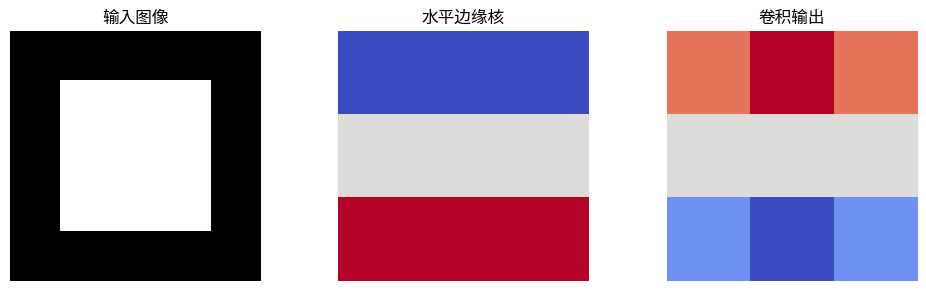

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("输入图像")
axes[1].imshow(edge_kernel, cmap="coolwarm")
axes[1].set_title("水平边缘核")
axes[2].imshow(output, cmap="coolwarm")
axes[2].set_title("卷积输出")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. CNN 的核心组件

典型 CNN 结构：

```text
输入图像 -> [卷积 -> 激活 -> 池化] × N -> 展平 -> 全连接 -> 输出
```

- **Conv2d**：提取局部模式，输出多个特征图。
- **ReLU**：引入非线性。
- **MaxPool2d**：降低空间分辨率，保留强响应。
- **BatchNorm2d**：稳定训练。
- **Flatten**：把特征图变成向量。
- **Linear**：根据提取的特征做分类。

In [4]:
x = torch.randn(1, 1, 28, 28)
print("输入:", list(x.shape))
conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
x1 = conv1(x)
print("Conv2d(1->16, k=3, p=1):", list(x1.shape))
pool = nn.MaxPool2d(2, 2)
x2 = pool(x1)
print("MaxPool2d(2):", list(x2.shape))
conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
x3 = conv2(x2)
print("Conv2d(16->32, k=3, p=1):", list(x3.shape))
x4 = pool(x3)
print("MaxPool2d(2):", list(x4.shape))
x5 = x4.flatten(1)
print("Flatten:", list(x5.shape))
fc = nn.Linear(32 * 7 * 7, 10)
x6 = fc(x5)
print("Linear -> 10:", list(x6.shape))

输入: [1, 1, 28, 28]
Conv2d(1->16, k=3, p=1): [1, 16, 28, 28]
MaxPool2d(2): [1, 16, 14, 14]
Conv2d(16->32, k=3, p=1): [1, 32, 14, 14]
MaxPool2d(2): [1, 32, 7, 7]
Flatten: [1, 1568]
Linear -> 10: [1, 10]


## 4. 构建 CNN 分类器

MNIST 图像大小是 1×28×28。下面的网络先用两个卷积块提取特征，再用全连接层输出 10 个类别的 logits。

注意：`nn.CrossEntropyLoss` 内部已经包含 Softmax，因此模型最后一层不要手动加 Softmax。

In [5]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = MNISTNet()
print(model)
print("总参数量:", f"{sum(p.numel() for p in model.parameters()):,}")
dummy = torch.randn(4, 1, 28, 28)
out = model(dummy)
print("输入形状:", list(dummy.shape), "输出形状:", list(out.shape))
assert out.shape == (4, 10)

MNISTNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
总参数量: 207,018
输入形状: [4, 1, 28, 28] 输出形状: [4, 10]


## 5. 在 MNIST 上训练

如果本地 `torchvision` 可用并且可以下载数据，就训练一个小规模 MNIST 示例。若网络或版本问题导致加载失败，Notebook 会用随机输入验证模型结构，保证前向传播逻辑正确。

In [6]:
try:
    if not HAS_TORCHVISION:
        raise RuntimeError(f"torchvision 不可用: {TORCHVISION_ERROR}")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST("./data", train=False, transform=transform)
    train_subset = torch.utils.data.Subset(train_dataset, range(2000))
    test_subset = torch.utils.data.Subset(test_dataset, range(500))
    train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

    torch.manual_seed(42)
    model = MNISTNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    print("--- 开始训练 ---")
    for epoch in range(3):
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        for batch_X, batch_y in train_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
        train_acc = correct / total

        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                predicted = outputs.argmax(dim=1)
                test_total += batch_y.size(0)
                test_correct += (predicted == batch_y).sum().item()
        test_acc = test_correct / test_total
        print(f"Epoch {epoch+1}/3: loss={running_loss/len(train_loader):.4f}, train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")
    assert test_acc > 0.80
    print("✓ CNN 在 MNIST 子集上训练成功")
except Exception as exc:
    print("注意：MNIST 数据加载或训练跳过。原因:", exc)
    model = MNISTNet()
    dummy_input = torch.randn(4, 1, 28, 28)
    dummy_output = model(dummy_input)
    print("随机输入形状:", list(dummy_input.shape))
    print("模型输出形状:", list(dummy_output.shape))
    assert dummy_output.shape == (4, 10)
    print("✓ 模型结构正确")

注意：MNIST 数据加载或训练跳过。原因: torchvision 不可用: operator torchvision::nms does not exist
随机输入形状: [4, 1, 28, 28]
模型输出形状: [4, 10]
✓ 模型结构正确


## 6. 总结与练习

关键要点：

1. CNN 用局部连接和参数共享减少参数量。
2. 卷积核像模式检测器，会在图像上滑动。
3. 池化降低空间尺寸并保留强响应。
4. CNN 典型结构是 Conv-BN-ReLU-Pool -> Flatten -> Linear。
5. 多分类训练用 `CrossEntropyLoss`，模型输出 logits 即可。

**练习**：改变卷积通道数、池化层、Dropout 比例，观察参数量和训练效果变化。

## 7. 深入理解：CNN 为什么适合图像

图像有很强的空间结构：相邻像素往往相关，边缘、角点、纹理都出现在局部区域。全连接网络忽略这种结构，把每个像素当成独立特征，因此参数量巨大。

CNN 的优势来自三个归纳偏置：

1. **局部性**：局部区域足以识别边缘、纹理等底层特征。
2. **共享性**：同一种特征检测器可以用于图像任意位置。
3. **层级性**：低层学边缘，高层组合成形状，再组合成物体部分。

这就是为什么 CNN 在图像任务上长期有效。它不是简单“参数更少”，而是把图像结构知识写进了模型结构。

## 8. 输出尺寸和通道数怎么思考

CNN 中最容易混乱的是形状。PyTorch 图像张量使用：

```text
(batch, channels, height, width)
```

例如 MNIST 是 `(batch, 1, 28, 28)`，RGB 图片通常是 `(batch, 3, H, W)`。

卷积层 `nn.Conv2d(in_channels, out_channels, kernel_size)` 中：

- `in_channels` 必须等于输入通道数。
- `out_channels` 是卷积核数量，也就是输出特征图数量。
- `kernel_size` 决定每次看的局部窗口大小。

调试 CNN 时，建议每经过一层就打印 shape，直到你能心算大部分尺寸变化。

## 9. CNN 常见错误

1. **Flatten 维度算错**
   解决：用 dummy input 跑一遍，打印 flatten 后形状。

2. **CrossEntropyLoss 前手动 Softmax**
   不需要。`nn.CrossEntropyLoss` 内部已经包含 `log_softmax`。

3. **通道顺序弄错**
   PyTorch 是 `(N,C,H,W)`，不是 `(N,H,W,C)`。

4. **训练集太小还用大模型**
   容易过拟合。可以加 Dropout、数据增强、weight decay，或减小模型。

5. **只看准确率不看错例**
   图像任务中看错例非常重要，能发现数据标注、预处理或类别混淆问题。

## 10. 手算一个卷积输出尺寸

理解 CNN 时，建议先熟悉这个公式：

$$H_{out}=\left\lfloor\frac{H_{in}+2P-K}{S}\right\rfloor+1$$

其中 $H_{in}$ 是输入高度，$K$ 是卷积核大小，$P$ 是 padding，$S$ 是 stride。宽度同理。

例如输入是 $28\times28$，卷积核 $3\times3$，padding 为 1，stride 为 1：

$$H_{out}=\frac{28+2-3}{1}+1=28$$

这说明 padding=1 的 3x3 卷积可以保持空间尺寸不变。随后如果接一个 2x2 max pooling，尺寸会从 28 变成 14。掌握这件事后，你就能更稳定地设计 `Linear` 层输入维度。

## 11. 卷积层学到的特征如何演化

CNN 的低层通常学到边缘、方向、局部纹理；中间层会组合成笔画、角点、局部形状；高层则更接近类别相关的结构。

以手写数字为例：

- 低层可能检测横线、竖线、斜线。
- 中层可能检测圆弧、交叉、闭合区域。
- 高层可能组合出“像 8 的两个环”或“像 1 的竖线”。

这个层级组合思想，是 CNN 比直接把像素交给全连接网络更自然的原因。初学时不必马上可视化所有卷积核，但要记住：卷积核不是人为指定的滤波器，而是在训练中从数据学出来的局部模式检测器。

## 12. 经典 CNN 架构：AlexNet 与 ResNet

学习 CNN 时，AlexNet 和 ResNet 是两个非常重要的里程碑。它们不只是历史名词，而是分别解决了深度学习视觉模型中的两个关键问题：大规模图像识别如何训练，以及网络变深后为什么还能稳定优化。

### AlexNet：让深度 CNN 在大规模视觉任务上爆发

AlexNet 在 2012 年 ImageNet 比赛中取得突破性结果，通常被看作深度学习在计算机视觉领域爆发的标志。它的核心意义是证明：只要有足够数据、算力和合适的训练技巧，较深的 CNN 可以显著超过传统手工特征方法。

AlexNet 的几个关键特点：

- 使用多层卷积和池化提取层级视觉特征。
- 使用 ReLU 作为激活函数，比 Sigmoid/Tanh 更容易训练深层网络。
- 使用 Dropout 缓解全连接层过拟合。
- 使用数据增强扩大训练样本的变化，例如随机裁剪、翻转。
- 借助 GPU 加速训练，让大模型训练变得现实。

初学者可以把 AlexNet 理解为：它把 LeNet 这类早期 CNN 思想扩展到更大数据、更深网络和更复杂图像任务上，展示了 CNN 的真正威力。

### ResNet：用残差连接解决深层网络退化问题

随着网络变深，直觉上模型表达能力应该更强。但实践中，人们发现普通网络变得很深以后，训练误差反而可能上升。这不一定是过拟合，而是优化变难了，称为退化问题。

ResNet 的核心思想是残差连接：让网络学习输入和目标之间的差值，而不是直接学习完整映射。一个残差块可以写成：

$$y = F(x) + x$$

其中 $x$ 是输入，$F(x)$ 是若干卷积层学习到的残差。这个结构有两个直觉好处：

- 如果某些层暂时学不到有用变换，模型至少可以通过 shortcut 近似保留原输入。
- 梯度可以沿 shortcut 更顺畅地向前层传播，深层网络更容易训练。

ResNet 的贡献不只是把网络堆得更深，而是给出了一个稳定训练深层 CNN 的通用结构。后来的很多视觉模型、检测模型和分割模型都大量使用残差连接。

### 两者对比

| 架构 | 主要贡献 | 初学者应记住的关键词 |
|------|----------|----------------------|
| AlexNet | 证明深度 CNN 能在大规模图像识别中取得突破 | ReLU、Dropout、数据增强、GPU |
| ResNet | 让非常深的网络可以稳定训练 | 残差连接、shortcut、梯度传播 |

如果说 AlexNet 证明了 CNN 的潜力，ResNet 则解决了把 CNN 做得更深时的训练稳定性问题。理解这两个模型，有助于你看懂现代视觉网络为什么既重视卷积特征提取，也重视网络连接方式。

## 13. 学完本节后应该能做到什么

你应该能够：

- 说清楚 `in_channels` 和 `out_channels` 的区别。
- 根据输入尺寸、卷积核、padding、stride 推出输出尺寸。
- 判断什么时候需要 `Flatten`，以及为什么它连接卷积特征和全连接分类器。
- 解释为什么池化会降低空间尺寸，同时保留主要响应。
- 说出 AlexNet 为什么重要，以及 ResNet 的残差连接解决了什么问题。
- 看到 shape mismatch 报错时，知道先打印每一层输出形状。

CNN 学习早期，shape 调试能力非常关键。模型结构越复杂，越要养成逐层检查的习惯。